In [1]:
import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'legend.fontsize':  10,
    'axes.linewidth':   0.8,
    'axes.grid':        True,
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
    'grid.alpha':       0.6,
    'figure.dpi':       150,
    'savefig.dpi':      300,
    'savefig.bbox':     'tight',
})

In [2]:
# ── Parse .out files ──────────────────────────────────────────────────────────
# Filename convention: {ranks}_{omp_threads}.out
# Only files ending in _64.out are used (64 OMP threads/rank)

BENCH_DIR  = os.path.dirname(os.path.abspath('__file__'))  # same dir as notebook
OMP_FILTER = 64   # only keep runs with this OMP thread count

def parse_out_file(path):
    """Return dict with ranks, omp_threads, throughput, latency_ms, std_ms.
    Returns None if the run produced no useful data (e.g. batches_per_rank=0)."""
    fname  = os.path.basename(path)                  # e.g. "4_64.out"
    stem   = fname.replace('.out', '')               # "4_64"
    parts  = stem.split('_')
    ranks  = int(parts[0])
    omp    = int(parts[1])

    with open(path) as f:
        text = f.read()

    def extract(pattern):
        m = re.search(pattern, text)
        return float(m.group(1)) if m else None

    throughput = extract(r'Throughput\s*:\s*([0-9]+\.?[0-9]*)')
    latency    = extract(r'Mean latency\s*:\s*([0-9]+\.?[0-9]*)')
    std        = extract(r'Std dev\s*:\s*([0-9]+\.?[0-9]*)')

    # Discard degenerate runs (0 batches processed)
    if throughput is None or throughput == 0 or latency == 0:
        return None

    return dict(ranks=ranks, omp=omp,
                throughput=throughput, latency=latency, std=std)


# Load all matching files
pattern = os.path.join(BENCH_DIR, f'*_{OMP_FILTER}.out')
records = []
for path in sorted(glob.glob(pattern)):
    rec = parse_out_file(path)
    if rec is not None:
        records.append(rec)
        print(f"  {os.path.basename(path):20s}  ranks={rec['ranks']:3d}  "
              f"throughput={rec['throughput']:>10,.1f} s/s  "
              f"latency={rec['latency']:.2f} ms")

records.sort(key=lambda r: r['ranks'])
print(f"\nLoaded {len(records)} valid runs with OMP_NUM_THREADS={OMP_FILTER}")

  16_64.out             ranks= 16  throughput=  54,792.7 s/s  latency=37.38 ms
  1_64.out              ranks=  1  throughput=   4,071.6 s/s  latency=31.44 ms
  2_64.out              ranks=  2  throughput=   7,949.1 s/s  latency=32.20 ms
  32_64.out             ranks= 32  throughput=  91,143.6 s/s  latency=44.94 ms
  4_64.out              ranks=  4  throughput=  15,772.9 s/s  latency=32.46 ms
  64_64.out             ranks= 64  throughput= 138,186.0 s/s  latency=59.28 ms
  8_64.out              ranks=  8  throughput=  29,741.6 s/s  latency=34.43 ms

Loaded 7 valid runs with OMP_NUM_THREADS=64


In [3]:
# ── Derived arrays ────────────────────────────────────────────────────────────
ranks      = np.array([r['ranks']      for r in records])
throughput = np.array([r['throughput'] for r in records])
latency    = np.array([r['latency']    for r in records])
std_dev    = np.array([r['std']        for r in records])

baseline      = throughput[0]                 # 1-rank throughput
speedup       = throughput / baseline
ideal_speedup = ranks.astype(float)
efficiency    = speedup / ideal_speedup * 100

print(f"{'Ranks':>6} {'Throughput':>14} {'Speedup':>8} {'Efficiency':>11} {'Latency':>10} {'Std':>8}")
print("-" * 65)
for i in range(len(ranks)):
    print(f"{ranks[i]:>6}  {throughput[i]:>12,.0f}/s  {speedup[i]:>7.2f}x  "
          f"{efficiency[i]:>10.1f}%  {latency[i]:>8.2f}ms  {std_dev[i]:>6.2f}ms")

 Ranks     Throughput  Speedup  Efficiency    Latency      Std
-----------------------------------------------------------------
     1         4,072/s     1.00x       100.0%     31.44ms    0.66ms
     2         7,949/s     1.95x        97.6%     32.20ms    5.31ms
     4        15,773/s     3.87x        96.8%     32.46ms    6.31ms
     8        29,742/s     7.30x        91.3%     34.43ms    9.19ms
    16        54,793/s    13.46x        84.1%     37.38ms   11.93ms
    32        91,144/s    22.39x        70.0%     44.94ms   14.34ms
    64       138,186/s    33.94x        53.0%     59.28ms    3.47ms


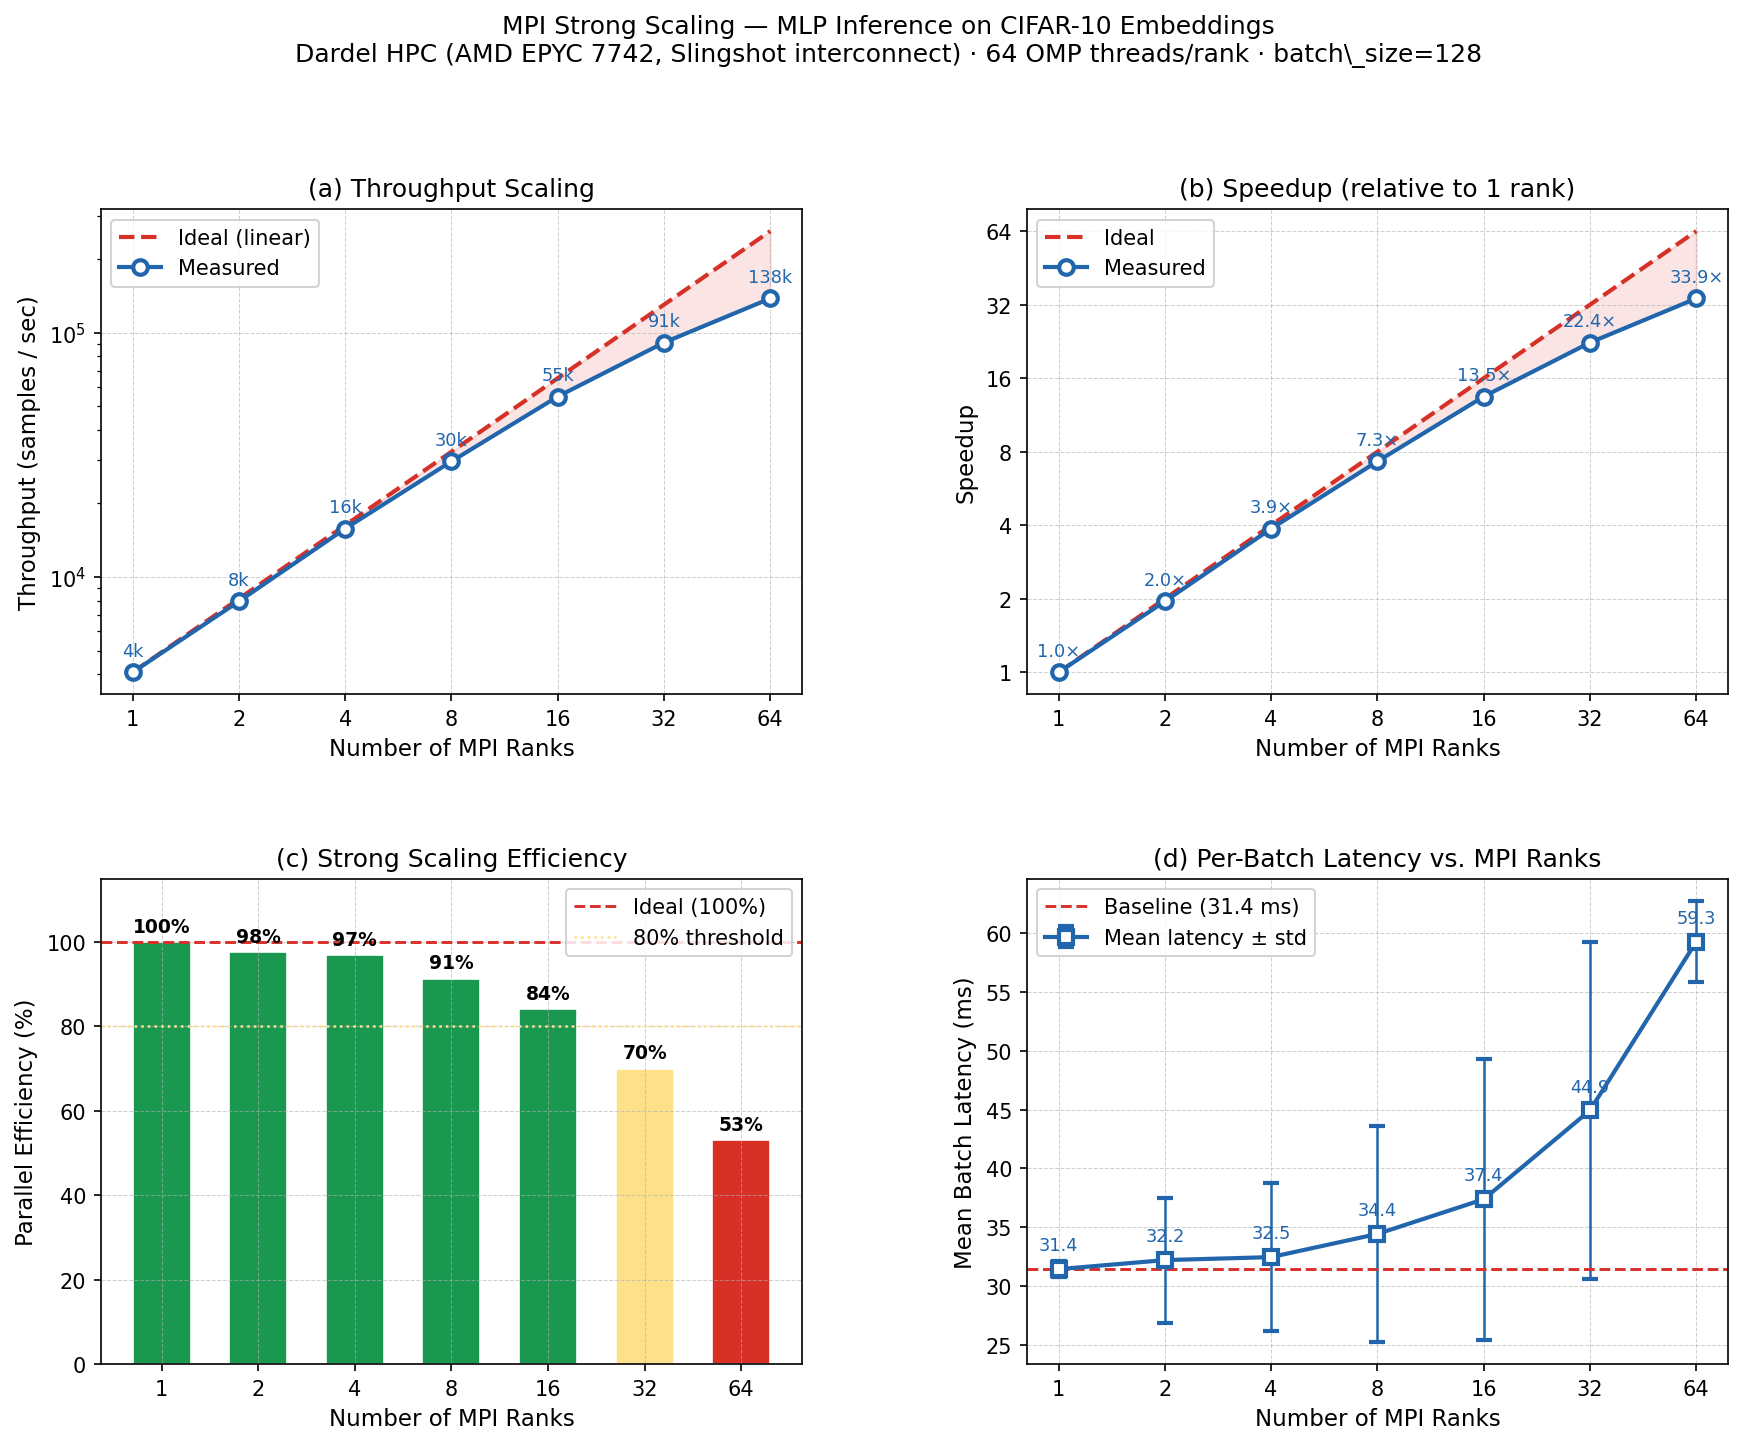

Saved mpi_strong_scaling.pdf / .png


In [4]:
# ── Colours ───────────────────────────────────────────────────────────────────
C_ACTUAL = '#2166AC'
C_IDEAL  = '#D73027'
C_EFF    = '#1A9850'

def bar_color(e):
    if e >= 80: return C_EFF
    if e >= 60: return '#FEE08B'
    return '#D73027'

marker_kw = dict(lw=2.0, ms=7, markerfacecolor='white', markeredgewidth=2)

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ─── (a) Throughput ───────────────────────────────────────────────────────────
ideal_tp = baseline * ranks
ax1.fill_between(ranks, throughput, ideal_tp, alpha=0.12, color=C_IDEAL)
ax1.plot(ranks, ideal_tp,  '--', color=C_IDEAL,  **marker_kw, label='Ideal (linear)')
ax1.plot(ranks, throughput, 'o-', color=C_ACTUAL, **marker_kw, label='Measured')
for r, tp in zip(ranks, throughput):
    ax1.annotate(f'{tp/1000:.0f}k', xy=(r, tp),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8.5, color=C_ACTUAL)
ax1.set_xscale('log', base=2)
ax1.set_yscale('log', base=10)
ax1.set_xticks(ranks)
ax1.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel('Number of MPI Ranks')
ax1.set_ylabel('Throughput (samples / sec)')
ax1.set_title('(a) Throughput Scaling')
ax1.legend(framealpha=0.85)

# ─── (b) Speedup ──────────────────────────────────────────────────────────────
ax2.fill_between(ranks, speedup, ideal_speedup, alpha=0.12, color=C_IDEAL)
ax2.plot(ranks, ideal_speedup, '--', color=C_IDEAL,  **marker_kw, label='Ideal')
ax2.plot(ranks, speedup,       'o-', color=C_ACTUAL, **marker_kw, label='Measured')
for r, s in zip(ranks, speedup):
    ax2.annotate(f'{s:.1f}×', xy=(r, s),
                 xytext=(0, 8), textcoords='offset points',
                 ha='center', fontsize=8.5, color=C_ACTUAL)
ax2.set_xscale('log', base=2)
ax2.set_yscale('log', base=2)
ax2.set_xticks(ranks)
yticks = [2**i for i in range(int(np.log2(ranks[-1]))+1)]
ax2.set_yticks(yticks)
ax2.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax2.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax2.set_xlabel('Number of MPI Ranks')
ax2.set_ylabel('Speedup')
ax2.set_title('(b) Speedup (relative to 1 rank)')
ax2.legend(framealpha=0.85)

# ─── (c) Efficiency ───────────────────────────────────────────────────────────
x = np.arange(len(ranks))
bars = ax3.bar(x, efficiency, color=[bar_color(e) for e in efficiency],
               edgecolor='white', linewidth=0.8, width=0.6)
ax3.axhline(100, color=C_IDEAL,    ls='--', lw=1.4, label='Ideal (100%)')
ax3.axhline(80,  color='#FEE08B',  ls=':',  lw=1.2, label='80% threshold')
for bar, e in zip(bars, efficiency):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{e:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([str(r) for r in ranks])
ax3.set_ylim(0, 115)
ax3.set_xlabel('Number of MPI Ranks')
ax3.set_ylabel('Parallel Efficiency (%)')
ax3.set_title('(c) Strong Scaling Efficiency')
ax3.legend(framealpha=0.85)

# ─── (d) Latency ──────────────────────────────────────────────────────────────
ax4.errorbar(ranks, latency, yerr=std_dev, fmt='s-', color=C_ACTUAL,
             **marker_kw, capsize=4, capthick=1.5, elinewidth=1.2,
             label='Mean latency ± std')
ax4.axhline(latency[0], color=C_IDEAL, ls='--', lw=1.4,
            label=f'Baseline ({latency[0]:.1f} ms)')
for r, lat in zip(ranks, latency):
    ax4.annotate(f'{lat:.1f}', xy=(r, lat),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', fontsize=8.5, color=C_ACTUAL)
ax4.set_xscale('log', base=2)
ax4.set_xticks(ranks)
ax4.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax4.set_xlabel('Number of MPI Ranks')
ax4.set_ylabel('Mean Batch Latency (ms)')
ax4.set_title('(d) Per-Batch Latency vs. MPI Ranks')
ax4.legend(framealpha=0.85)

# ─── Suptitle ─────────────────────────────────────────────────────────────────
fig.suptitle(
    f'MPI Strong Scaling — MLP Inference on CIFAR-10 Embeddings\n'
    f'Dardel HPC (AMD EPYC 7742, Slingshot interconnect) · '
    f'{OMP_FILTER} OMP threads/rank · batch\_size=128',
    fontsize=12, y=1.01
)

plt.savefig(os.path.join(BENCH_DIR, 'mpi_strong_scaling.pdf'))
plt.savefig(os.path.join(BENCH_DIR, 'mpi_strong_scaling.png'))
plt.show()
print('Saved mpi_strong_scaling.pdf / .png')